# Performance Summary — Statistical Arbitrage Research Platform


Phase 1's real exchange data ingestion (`quant_project.data`) needs network
access this notebook deliberately doesn't require, so — exactly like
`main.py` — it runs on a small deterministic synthetic price panel instead.
Swap `synthetic_prices()` below for `quant_project.data.load_universe_ohlcv`
once you're ready to point this at a real exchange; nothing past that cell
needs to change.

**Re-run this whole notebook (Kernel → Restart & Run All) any time the
underlying signals, backtest, or combination logic changes — every cell
below recomputes from the current code, so the charts and tables you get
are never stale (Feature 6.7).**


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quant_project.backtest import run_multi_strategy_backtest
from quant_project.combination import combine_signals
from quant_project.performance import build_performance_report
from quant_project.signals.momentum import ema_crossover_momentum, time_horizon_momentum
from quant_project.signals.reversal import time_horizon_reversal

ASSETS = ["BTC", "ETH", "SOL", "AVAX"]
N_PERIODS = 250
SEED = 7


def synthetic_prices() -> pd.DataFrame:
    """Deterministic random-walk daily prices — mirrors main.py's
    generator, so results here match a `python main.py` run."""
    rng = np.random.default_rng(SEED)
    daily_returns = rng.normal(loc=0.0003, scale=0.02, size=(N_PERIODS, len(ASSETS)))
    prices = 100 * np.exp(np.cumsum(daily_returns, axis=0))
    index = pd.date_range("2024-01-01", periods=N_PERIODS, freq="D")
    return pd.DataFrame(prices, index=index, columns=ASSETS)


prices = synthetic_prices()
returns = prices.pct_change()
benchmark_returns = returns["BTC"]  # per specs/requirement-spec.md: "e.g. BTC"
prices.tail()

,BTC,ETH,SOL,AVAX
2024-09-02,97.472412,55.136627,96.698276,58.298501
2024-09-03,99.517141,54.997057,98.775804,58.336945
2024-09-04,99.361442,55.648267,100.919234,57.957322
2024-09-05,98.907879,55.486198,101.116763,56.940038
2024-09-06,100.992779,55.060144,102.086938,56.024511


## Individual strategies

Three signals from `quant_project.signals`, each run through the
unconstrained backtester on its own.


In [2]:
signals = {
    "momentum_7d": time_horizon_momentum(prices, lookback=7),
    "ema_crossover": ema_crossover_momentum(prices, fast_span=8, slow_span=24),
    "reversal_1d": time_horizon_reversal(prices, lookback=1),
}

results = run_multi_strategy_backtest(signals, returns)
reports = {
    name: build_performance_report(result, benchmark_returns=benchmark_returns)
    for name, result in results.items()
}
list(reports.keys())

['momentum_7d', 'ema_crossover', 'reversal_1d']

## Strategy combination

The same three signals, blended one way per weighting method
(`quant_project.combination`), then backtested and reported exactly like an
individual strategy above.


In [3]:
combined_reports = {}
for method, kwargs in [
    ("equal", {}),
    ("inverse_vol", {"strategy_returns": {n: r.net_returns for n, r in results.items()}}),
    ("ic", {"forward_returns": returns}),
]:
    combined_signal = combine_signals(signals, method=method, **kwargs)
    combined_result = run_multi_strategy_backtest({method: combined_signal}, returns)[method]
    combined_reports[f"combined_{method}"] = build_performance_report(
        combined_result, benchmark_returns=benchmark_returns
    )

all_reports = {**reports, **combined_reports}
list(combined_reports.keys())

['combined_equal', 'combined_inverse_vol', 'combined_ic']

## Metrics table (6.2–6.5)

Annualized return/volatility, Sharpe, max drawdown, and alpha/beta vs. BTC
— for every individual and combined strategy above.


In [4]:
metrics = pd.DataFrame(
    {
        name: {
            "ann_return": r.annualized_return,
            "ann_vol": r.annualized_volatility,
            "sharpe": r.sharpe_ratio,
            "max_drawdown": r.max_drawdown,
            "alpha": r.alpha,
            "beta": r.beta,
        }
        for name, r in all_reports.items()
    }
).T
metrics.style.format(
    {
        "ann_return": "{:+.2%}",
        "ann_vol": "{:.2%}",
        "sharpe": "{:+.2f}",
        "max_drawdown": "{:.2%}",
        "alpha": "{:+.2%}",
        "beta": "{:+.2f}",
    }
)

,ann_return,ann_vol,sharpe,max_drawdown,alpha,beta
momentum_7d,-25.62%,20.39%,-1.26,-18.35%,-24.62%,+0.08
ema_crossover,-8.52%,19.37%,-0.44,-17.76%,-7.74%,+0.13
reversal_1d,-75.56%,21.31%,-3.55,-61.90%,-75.17%,+0.02
combined_equal,-55.53%,21.52%,-2.58,-42.60%,-55.08%,+0.13
combined_inverse_vol,-52.59%,21.47%,-2.45,-40.02%,-52.10%,+0.13
combined_ic,-23.17%,20.64%,-1.12,-17.51%,-22.18%,+0.10


## Gross vs. net-of-cost cumulative returns (6.1)


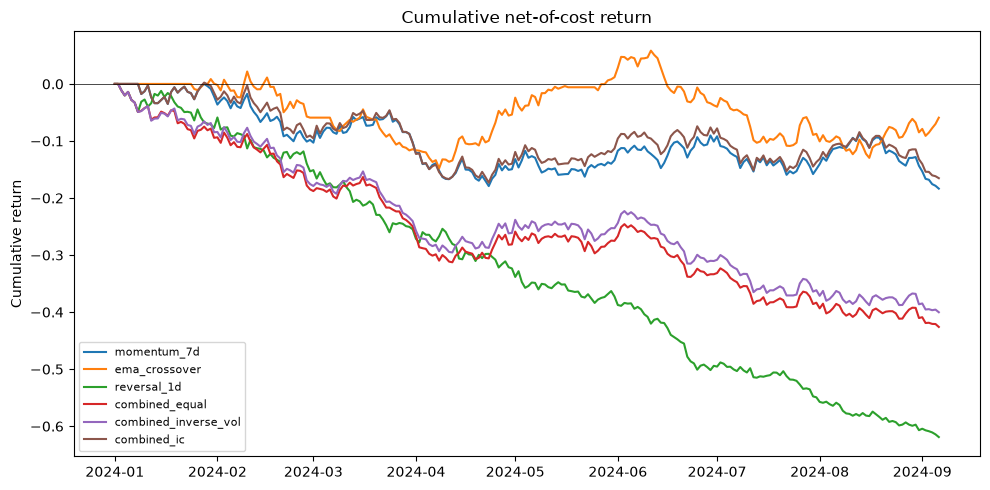

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, r in all_reports.items():
    ax.plot(r.cumulative_net.index, r.cumulative_net.values, label=name)
ax.set_title("Cumulative net-of-cost return")
ax.set_ylabel("Cumulative return")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

## Drawdown (6.4 / 6.6)


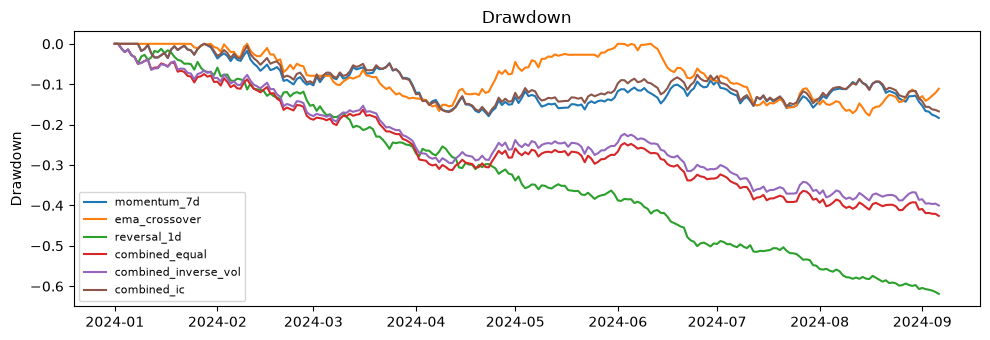

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for name, r in all_reports.items():
    ax.plot(r.drawdown.index, r.drawdown.values, label=name)
ax.set_title("Drawdown")
ax.set_ylabel("Drawdown")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()